## RL Book Graphics 4 - Policy Gradient Training Runs
- Picks up where `rl_book_graphics_2` left off: same 2-parameter policy, same stochastic return landscape, same starting point $\theta = (-0.5, 0.0)$.
- Four training runs, each with a path-on-landscape plot and a return-vs-step plot:
  1. Trajectory-level rewards: every action in an episode is weighted by the full return $R(\tau)$
  2. Negative example: drop the log, so we follow $R(\tau)\,\nabla_\theta p_\theta(\tau)$ instead of $R(\tau)\,\nabla_\theta \log p_\theta(\tau)$ (no $1/p$)
  3. Return-to-go: action $t$ is weighted by $G_t = \sum_{t' \geq t} r_{t'}$
  4. GRPO: 4 episodes per step, group-relative advantages $A_i = (R_i - \bar{R}) / \sigma_R$
- Run 1 also gets state-space snapshots every `SNAPSHOT_EVERY` episodes, and pink-dot versions of its two plots.
- Every run uses the same seeds (episode $k$ always uses env seed $k$), so the first episode of each run is identical and the runs are directly comparable.

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path as FilePath
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle

CHILL_BROWN="#948979"
FRESH_TAN="#f4ebd9"
ORANGE='#eb8423'
LT_BLUE='#5badb6'
GREEN='#419c52'
RED='#d73b2f'
PINK='#ed5e78'
YELLOW='#fcc947'

DATA = FilePath("/Users/stephen/ai_book_vol_2/chapters/08-reinforcement-learning/data")

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_orange", [LT_BLUE, ORANGE], N=256)

In [2]:
SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/8_reinforcement_learning/graphics'
# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/8_reinforcement_learning/graphics/'



In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [4]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def style_cbar(cbar, color=CHILL_BROWN):
    cbar.outline.set_edgecolor(color)
    cbar.ax.tick_params(colors=color, which='both')
    cbar.ax.yaxis.label.set_color(color)
    cbar.ax.xaxis.label.set_color(color)
    cbar.ax.title.set_color(color)

def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

In [5]:
VEL_SCALE = 10        # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
ANG_LIM = (-15, 15)   # state space plot limits
VEL_LIM = (-15, 15)

class Pi(nn.Module):
    # Two-parameter policy: P(right) = sigmoid(theta1 * pole_angle + theta2 * pole_ang_velocity)
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))

    def forward(self, x):
        logit = x @ self.theta.to(x.dtype)   # compute at the precision of the input
        return torch.sigmoid(logit)

def to_features(state):
    # Gymnasium state [x, x_dot, angle, ang_vel] (radians) -> our 2 features (degrees, ang vel / VEL_SCALE)
    f = torch.tensor(state[2:4], dtype=torch.float32) * 180/np.pi
    f[1] = f[1] / VEL_SCALE
    return f

def run_episode_stochastic(agent, env_seed, policy_seed, max_steps=500):
    # Push right with probability yhat. Returns features (T, 2) and actions (T,)
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=env_seed)
    rng = np.random.default_rng(policy_seed)   # policy randomness, independent of the starting state
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(rng.random() < agent(features))
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

def yhat_grid_at(theta, n=128):
    # Policy output over a grid of states, for a given theta (numpy, no agent needed)
    A, V = np.meshgrid(np.linspace(*ANG_LIM, n), np.linspace(*VEL_LIM, n))
    return A, V, 1/(1 + np.exp(-(theta[0]*A + theta[1]*V)))

def plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.5):   # shaded regions + decision boundary
    im = ax.imshow(yhat_grid, origin='lower', vmin=0, vmax=1, cmap=cmap,
                   extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=alpha)
    ax.contour(A, V, yhat_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    return im

def plot_state_space(ax, X_ep, y_ep, s=120):
    m = (y_ep == 1)
    ax.plot(X_ep[:,0], X_ep[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
    ax.scatter(X_ep[m, 0],  X_ep[m, 1],  marker=RIGHT_ARROW, s=s, color=ORANGE,  linewidths=0)
    ax.scatter(X_ep[~m, 0], X_ep[~m, 1], marker=LEFT_ARROW,  s=s, color=LT_BLUE, linewidths=0)
    ax.scatter(X_ep[0, 0],  X_ep[0, 1],  marker=RIGHT_ARROW if y_ep[0]==1  else LEFT_ARROW, s=s*1.3, color='g', linewidths=0)
    ax.scatter(X_ep[-1, 0], X_ep[-1, 1], marker=RIGHT_ARROW if y_ep[-1]==1 else LEFT_ARROW, s=s*1.3, color='r', linewidths=0)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)

### Return landscape (stochastic policy)

In [6]:
f = np.load(DATA / 'return_landscape_stochastic_256x256_1024_-1.0+1.0.npz')
R_mean_sto = f['R_mean']
theta1_vals_R = f['theta1_vals']
theta2_vals_R = f['theta2_vals'] if 'theta2_vals' in f.files else f['theta1_vals']
extent_R = [theta1_vals_R[0], theta1_vals_R[-1], theta2_vals_R[0], theta2_vals_R[-1]]

### Training machinery
- One function covers all four runs. Each step samples `group_size` episodes from the current policy, then takes one gradient *ascent* step.
- `weighting`: `'trajectory'` ($R(\tau)$ on every action), `'rtg'` (return-to-go $G_t$), or `'grpo'` (group-relative advantage on every action).
- `use_log=False` is the negative example: maximize $R(\tau)\,p_\theta(\tau)$ directly, so the gradient is $R(\tau)\,\nabla_\theta p_\theta(\tau)$, with no $1/p$. `no_log_form='per_step'` gives the slides_rl_4 version instead, $\sum_t G_t\, p_\theta(a_t|s_t)$.
- Episode $k$ (counted across the whole run) uses env seed `seed_offset + k`, so runs share seeds.
- Learning rates are in the same $\theta$ units as the landscape here (degree features). The slides notebooks used radian features, so their learning rates are bigger by a factor of $(180/\pi)^2 \approx 3283$.

In [7]:
CartPole_reward = 1.0   # +1 per step, gamma = 1 -> R(tau) = episode length, G_t = T - t

def train_pg(weighting='trajectory', use_log=True, no_log_form='trajectory',
             theta_0=(-0.5, 0.0), lr=2e-5, max_steps=3000, group_size=1,
             seed_offset=0, stop_after_first_500=20, theta_lim=1.0,
             max_step_norm=None, print_every=100):
    agent = Pi()
    with torch.no_grad(): agent.theta[:] = torch.tensor(theta_0)

    hist, k, first_500 = [], 0, None
    for step in tqdm(range(max_steps)):
        theta_before = agent.theta.detach().numpy().copy()

        # --- sample a group of episodes from the current policy ---
        group = [run_episode_stochastic(agent, env_seed=seed_offset + k + i,
                                        policy_seed=1_000_000 + seed_offset + k + i)
                 for i in range(group_size)]
        k += group_size
        Rs = np.array([CartPole_reward * len(y_ep) for _, y_ep in group])
        advs = (Rs - Rs.mean()) / (Rs.std() + 1e-8) if weighting == 'grpo' else None

        # --- surrogate objective; its gradient is the policy gradient estimate ---
        objective = 0.0
        for i, (X_ep, y_ep) in enumerate(group):
            x    = X_ep.double()                                 # float64: p(tau) underflows float32 on long episodes
            yhat = agent(x)
            p_t  = torch.where(y_ep == 1, yhat, 1 - yhat)        # probability of each action actually taken
            T    = len(y_ep)
            if weighting == 'trajectory': w = torch.full((T,), float(Rs[i]), dtype=torch.float64)
            elif weighting == 'rtg':      w = CartPole_reward * torch.arange(T, 0, -1, dtype=torch.float64)   # G_t = T - t
            elif weighting == 'grpo':     w = torch.full((T,), float(advs[i]), dtype=torch.float64)
            else: raise ValueError(weighting)

            if use_log:
                objective = objective + (w * torch.log(p_t)).sum()        # sum_t w_t log p(a_t|s_t)
            elif no_log_form == 'trajectory':
                objective = objective + w[0] * p_t.prod()                  # R(tau) * p(tau) -> grad is R grad p, no 1/p
            else:
                objective = objective + (w * p_t).sum()                    # sum_t w_t p(a_t|s_t)
        objective = objective / group_size

        agent.zero_grad()
        objective.backward()
        grad = agent.theta.grad.detach().numpy().copy()   # ascent direction

        # --- gradient ascent step (plain SGD, optionally length-capped) ---
        delta = lr * grad
        if max_step_norm is not None and np.linalg.norm(delta) > max_step_norm:
            delta = delta * max_step_norm / np.linalg.norm(delta)
        with torch.no_grad(): agent.theta += torch.tensor(delta, dtype=agent.theta.dtype)

        hist.append({'theta': theta_before, 'grad': grad, 'Rs': Rs, 'advs': advs,
                     'episodes': [(X.numpy(), y.numpy()) for X, y in group]})

        if print_every and (step % print_every == 0):
            print(f'step {step:5d}  mean R {Rs.mean():6.1f}  theta = ({theta_before[0]:+.3f}, {theta_before[1]:+.3f})')

        if first_500 is None and Rs.min() == 500:
            first_500 = step
            print(f'first all-500 step: {step}')
        if first_500 is not None and stop_after_first_500 is not None and step >= first_500 + stop_after_first_500:
            break
        if np.abs(agent.theta.detach().numpy()).max() > theta_lim:
            print(f'left the landscape at step {step}')
            break

    traj = np.array([h['theta'] for h in hist] + [agent.theta.detach().numpy().copy()])   # traj[s] = theta that played step s
    print(f'{len(hist)} steps, {k} episodes, final theta = ({traj[-1,0]:+.3f}, {traj[-1,1]:+.3f})')
    return hist, traj, agent

In [80]:
def flatten_episodes(hist):
    # One row per episode: (step it was played at, return, X, y)
    rows = []
    for s, h in enumerate(hist):
        for (X, y), R in zip(h['episodes'], h['Rs']):
            rows.append((s, R, X, y))
    return rows

def plot_training_path(traj, hist=None, snapshot_eps=None, ax=None, path_color='w', dot_color=PINK,
                       dot_size=14, show_cbar=True, contours=True, save_name=None):
    # Learning path on the stochastic return landscape. snapshot_eps -> pink dots at the theta that played them
    if ax is None:
        fig = plt.figure(0, (6, 6)); fig.clf(); ax = fig.add_subplot(111)
    im = ax.imshow(R_mean_sto.T, origin='lower', cmap='viridis', extent=extent_R, aspect='equal')
    if contours:
        T1, T2 = np.meshgrid(theta1_vals_R, theta2_vals_R)
        ax.contour(T1, T2, R_mean_sto.T, levels=20, colors='w', linewidths=0.5, alpha=0.4)
    ax.plot(traj[:, 0], traj[:, 1], color=path_color, lw=1.5, alpha=0.9, zorder=4)
    if snapshot_eps is not None and len(snapshot_eps):
        eps = flatten_episodes(hist)
        pts = np.array([traj[eps[k][0]] for k in snapshot_eps])
        ax.scatter(pts[:, 0], pts[:, 1], s=dot_size, color=dot_color, linewidths=0, zorder=8)
    ax.scatter(*traj[0],  s=70, color=GREEN, zorder=10)
    ax.scatter(*traj[-1], s=70, color=RED,   zorder=10)
    ax.set_xlim(extent_R[0], extent_R[1]); ax.set_ylim(extent_R[2], extent_R[3])
    ax.set_xticks([-1, -0.5, 0, 0.5, 1]); ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xlabel(r'$\theta_1$ (pole angle parameter)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity parameter)')
    style_ax(ax)
    if show_cbar:
        cbar = plt.colorbar(im, ax=ax, label='Average episode length (Return)', shrink=0.8); style_cbar(cbar)
    if save_name: plt.savefig(SAVE_DIR + '/' + save_name, bbox_inches='tight')
    return ax

def plot_training_rewards(hist, snapshot_eps=None, window=25, ax=None, figsize=(6, 3),
                          raw_color=LT_BLUE, mean_color=CHILL_BROWN, dot_color=PINK, dot_size=14,
                          xlabel='Learning step', ylim=(0, 520), save_name=None):
    # Return vs learning step: every episode as a faint dot, plus a trailing running mean of the per-step mean return
    if ax is None:
        fig = plt.figure(0, figsize); fig.clf(); ax = fig.add_subplot(111)
    eps = flatten_episodes(hist)
    s_all = np.array([e[0] for e in eps]); R_all = np.array([e[1] for e in eps])
    ax.scatter(s_all, R_all, s=6, color=raw_color, alpha=0.35, linewidths=0, zorder=2)
    R_step = np.array([h['Rs'].mean() for h in hist])
    c = np.cumsum(np.insert(R_step, 0, 0.0))
    run = np.array([(c[i+1] - c[max(0, i+1-window)]) / (i+1 - max(0, i+1-window)) for i in range(len(R_step))])
    ax.plot(np.arange(len(R_step)), run, color=mean_color, lw=1.8, zorder=3)
    if snapshot_eps is not None and len(snapshot_eps):
        ax.scatter(s_all[snapshot_eps], R_all[snapshot_eps], s=dot_size, color=dot_color, linewidths=0, zorder=8)
    ax.set_xlabel(xlabel); ax.set_ylabel('Return (episode length)')
    ax.set_ylim(*ylim)
    style_ax(ax)
    if save_name: plt.savefig(SAVE_DIR + '/' + save_name, bbox_inches='tight')
    return ax

def plot_snapshot(ax, theta, X_ep, y_ep, s=200, label=None, alpha=0.35):
    # One state space panel: policy that played the episode + the episode itself
    A, V, yg = yhat_grid_at(theta)
    plot_yhat_grid(ax, A, V, yg, alpha=alpha)
    plot_state_space(ax, X_ep, y_ep, s=s)
    ax.text(0.97, 0.03, f'{len(y_ep)} steps', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=18, color=CHILL_BROWN)
    if label is not None:
        ax.text(0.03, 0.97, label, transform=ax.transAxes, ha='left', va='top', fontsize=18, color=CHILL_BROWN)
    ax.set_xticks([-10, 0, 10]); ax.set_yticks([-10, 0, 10])
    style_ax(ax)

## 1. Trajectory-level rewards
$$
\theta \leftarrow \theta + \alpha \, R(\tau) \sum_{t=1}^{T} \nabla_{\theta} \log p_{\theta}(a_t \mid s_t)
$$
- One episode per step. `LR_TRAJ=2e-5` gets to 500 in roughly 1400-1600 episodes. Much bigger and a single long episode can launch $\theta$ off the landscape (gradient scales with $R \cdot T$); `max_step_norm` caps the step length if you want a tamer path.

- Quick high LR variant

In [9]:
THETA_0 = (-0.5, 0.0)
LR_TRAJ = 1e-4#2e-5

hist_traj, traj_traj, agent_traj = train_pg(weighting='trajectory', theta_0=THETA_0, lr=LR_TRAJ,
                                            max_steps=3000, stop_after_first_500=1)

 11%|███▊                              | 331/3000 [00:00<00:01, 1649.93it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
step   100  mean R   10.0  theta = (-0.460, +0.043)
step   200  mean R   10.0  theta = (-0.340, +0.159)
step   300  mean R   14.0  theta = (-0.394, +0.197)
left the landscape at step 331
332 steps, 332 episodes, final theta = (-0.361, +1.080)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

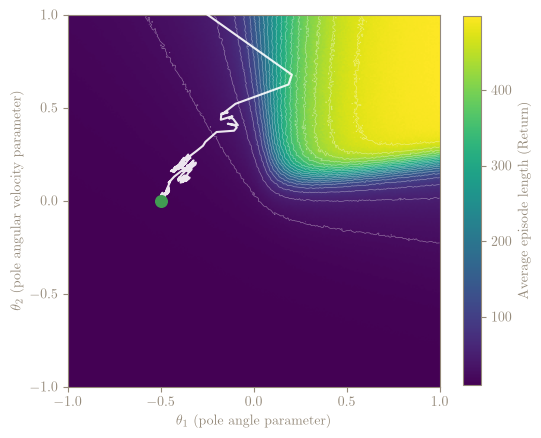

In [10]:
plot_training_path(traj_traj, save_name='pg_traj_path_lr_1e4.svg')

In [11]:
THETA_0 = (-0.5, 0.0)
LR_TRAJ = 1e-3#2e-5

hist_traj, traj_traj, agent_traj = train_pg(weighting='trajectory', theta_0=THETA_0, lr=LR_TRAJ,
                                            max_steps=3000, stop_after_first_500=1)

  1%|▎                                   | 24/3000 [00:00<00:03, 920.11it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
left the landscape at step 24
25 steps, 25 episodes, final theta = (-1.031, +0.270)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

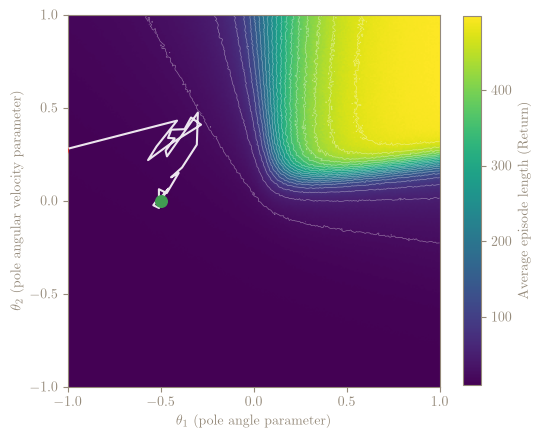

In [12]:
plot_training_path(traj_traj, save_name='pg_traj_path_lr_1e3.svg')

In [13]:
THETA_0 = (-0.5, 0.0)
LR_TRAJ = 2e-5#2e-5

hist_traj, traj_traj, agent_traj = train_pg(weighting='trajectory', theta_0=THETA_0, lr=LR_TRAJ,
                                            max_steps=3000, stop_after_first_500=1)

 14%|████▊                             | 430/3000 [00:00<00:01, 2155.77it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
step   100  mean R   10.0  theta = (-0.498, +0.005)
step   200  mean R   10.0  theta = (-0.481, +0.030)
step   300  mean R   12.0  theta = (-0.479, +0.049)
step   400  mean R   11.0  theta = (-0.465, +0.056)


 29%|█████████▋                        | 860/3000 [00:00<00:01, 2117.02it/s]

step   500  mean R   11.0  theta = (-0.446, +0.074)
step   600  mean R   10.0  theta = (-0.425, +0.094)
step   700  mean R    8.0  theta = (-0.427, +0.081)
step   800  mean R   14.0  theta = (-0.397, +0.099)
step   900  mean R    9.0  theta = (-0.340, +0.155)


 42%|██████████████                   | 1273/3000 [00:00<00:00, 1805.92it/s]

step  1000  mean R   20.0  theta = (-0.288, +0.199)
step  1100  mean R   13.0  theta = (-0.288, +0.204)
step  1200  mean R   35.0  theta = (-0.212, +0.286)
step  1300  mean R   23.0  theta = (-0.231, +0.305)


 47%|███████████████▌                 | 1411/3000 [00:00<00:00, 1721.54it/s]

step  1400  mean R   54.0  theta = (-0.020, +0.459)
first all-500 step: 1410
1412 steps, 1412 episodes, final theta = (+0.613, +0.730)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

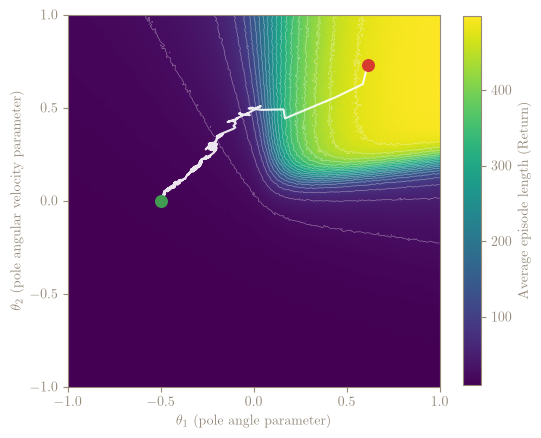

In [14]:
plot_training_path(traj_traj, save_name='pg_traj_path_2e5.svg')

In [15]:
THETA_0 = (-0.5, 0.0)
LR_TRAJ = 4e-5#2e-5

hist_traj, traj_traj, agent_traj = train_pg(weighting='trajectory', theta_0=THETA_0, lr=LR_TRAJ,
                                            max_steps=3000, stop_after_first_500=1)

 14%|████▋                             | 412/3000 [00:00<00:01, 2054.35it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
step   100  mean R   10.0  theta = (-0.494, +0.010)
step   200  mean R   10.0  theta = (-0.461, +0.056)
step   300  mean R   13.0  theta = (-0.449, +0.111)
step   400  mean R   15.0  theta = (-0.424, +0.103)


 28%|█████████▍                        | 832/3000 [00:00<00:01, 2068.58it/s]

step   500  mean R   12.0  theta = (-0.351, +0.146)
step   600  mean R   10.0  theta = (-0.381, +0.109)
step   700  mean R    8.0  theta = (-0.388, +0.064)
step   800  mean R   14.0  theta = (-0.356, +0.078)
step   900  mean R    9.0  theta = (-0.232, +0.177)


 34%|███████████                      | 1011/3000 [00:00<00:01, 1877.16it/s]

step  1000  mean R   26.0  theta = (-0.107, +0.313)
first all-500 step: 1011
left the landscape at step 1011
1012 steps, 1012 episodes, final theta = (+1.021, -0.295)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

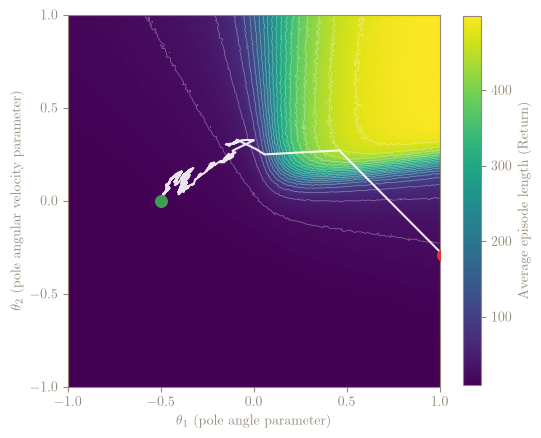

In [16]:
plot_training_path(traj_traj, save_name='pg_traj_path_4e5.svg')

In [17]:
# plot_training_rewards(hist_traj, window=25, save_name='pg_traj_rewards.svg')

### State space snapshots every `SNAPSHOT_EVERY` episodes
- Each panel shows the episode on top of the policy that played it. One svg per snapshot goes into `SAVE_DIR/pg_traj_snapshots/`, plus a contact sheet for a quick look.

In [18]:
SNAPSHOT_EVERY = 25     # every Nth training episode
SAVE_SNAPSHOTS = True   # individual svgs, one per snapshot
SNAP_SIZE      = 3      # inches, individual panels
SHEET_COLS     = 10     # contact sheet columns

eps_traj = flatten_episodes(hist_traj)
snap_traj = np.arange(0, len(eps_traj), SNAPSHOT_EVERY)
if snap_traj[-1] != len(eps_traj) - 1:
    snap_traj = np.append(snap_traj, len(eps_traj) - 1)
print(f'{len(snap_traj)} snapshots')

if SAVE_SNAPSHOTS:
    snap_dir = FilePath(SAVE_DIR) / 'pg_traj_snapshots_2'
    snap_dir.mkdir(parents=True, exist_ok=True)
    for k in tqdm(snap_traj):
        s, R, X_ep, y_ep = eps_traj[k]
        fig = plt.figure(figsize=(SNAP_SIZE, SNAP_SIZE)); ax = fig.add_subplot(111)
        plot_snapshot(ax, traj_traj[s], X_ep, y_ep, s=300)
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        fig.savefig(snap_dir / f'episode_{k:04d}.svg', bbox_inches='tight')
        plt.close(fig)

42 snapshots


100%|███████████████████████████████████████| 42/42 [00:06<00:00,  6.33it/s]


In [19]:
# n_rows = int(np.ceil(len(snap_traj) / SHEET_COLS))
# fig, axs = plt.subplots(n_rows, SHEET_COLS, figsize=(1.6*SHEET_COLS, 1.6*n_rows), sharex=True, sharey=True)
# for ax in axs.ravel(): ax.axis('off')
# for ax, k in zip(axs.ravel(), snap_traj):
#     ax.axis('on')
#     s, R, X_ep, y_ep = eps_traj[k]
#     plot_snapshot(ax, traj_traj[s], X_ep, y_ep, s=30, label=f'{k}')
#     ax.tick_params(labelsize=6)
#     for t in ax.texts: t.set_fontsize(7)
# plt.tight_layout()
# plt.savefig(SAVE_DIR + '/pg_traj_snapshots_sheet.svg', bbox_inches='tight')

100%|██████████████████████████████████| 1000/1000 [00:09<00:00, 101.90it/s]


theta = (+0.461, +0.270)  episode length: mean 442.0  min 15  max 500


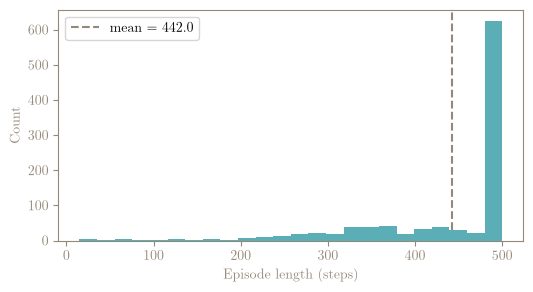

In [20]:
# --- Return histogram for the policy that played the final snapshot episode ---
N_ROLLOUTS = 1000
ENV_SEED   = 0      # same start every time, like the theta_0 histogram in graphics_2; set None to vary starts

k_final = snap_traj[-1]
s_final = eps_traj[k_final][0]                  # training step that episode was played at
theta_final = traj_traj[s_final]

agent_final = Pi()
with torch.no_grad(): agent_final.theta[:] = torch.tensor(theta_final, dtype=torch.float32)

rollouts_final = [run_episode_stochastic(agent_final, env_seed=(ENV_SEED if ENV_SEED is not None else i), policy_seed=i)
                  for i in tqdm(range(N_ROLLOUTS))]
lengths_final = np.array([len(y_ep) for _, y_ep in rollouts_final])
print(f'theta = ({theta_final[0]:+.3f}, {theta_final[1]:+.3f})  episode length: mean {lengths_final.mean():.1f}  min {lengths_final.min()}  max {lengths_final.max()}')

fig=plt.figure(0, (6, 3))
ax=fig.add_subplot(111)
plt.hist(lengths_final, bins=24, color=LT_BLUE, zorder=3)
plt.axvline(lengths_final.mean(), color=CHILL_BROWN, ls='--', label=f'mean = {lengths_final.mean():.1f}')
plt.xlabel('Episode length (steps)'); plt.ylabel('Count'); plt.legend()
style_ax(ax)
for artist in ax.get_children():
    artist.set_clip_on(False)

plt.savefig(SAVE_DIR + '/pg_traj_final_snapshot_hist.svg', bbox_inches='tight')

<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

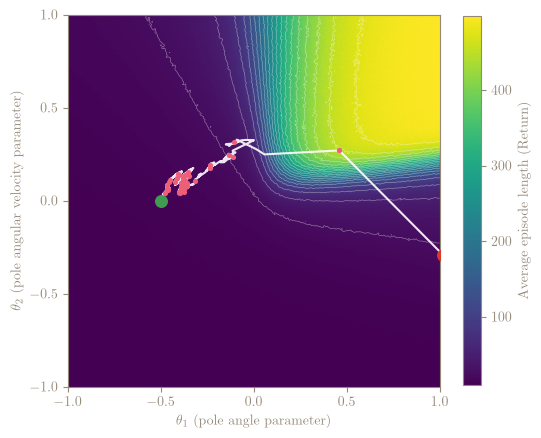

In [21]:
plot_training_path(traj_traj, hist=hist_traj, snapshot_eps=snap_traj, save_name='pg_traj_path_snapshots.svg')

<Axes: xlabel='Learning step', ylabel='Return (episode length)'>

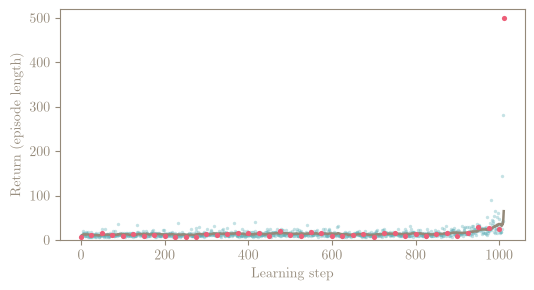

In [22]:
plot_training_rewards(hist_traj, snapshot_eps=snap_traj, window=25, save_name='pg_traj_rewards_snapshots.svg')

## 2. Negative example: delete the log (no $1/p$)
$$
\theta \leftarrow \theta + \alpha \, R(\tau) \, \nabla_{\theta} p_{\theta}(\tau)
\qquad \text{instead of} \qquad
\theta \leftarrow \theta + \alpha \, R(\tau) \, \nabla_{\theta} \log p_{\theta}(\tau)
$$
- Without the $1/p$, episodes the policy already likes get pushed hardest. From $(-0.5, 0)$ the (bad) policy is fairly confident, so $\theta$ walks down-left, away from the reward peak, and returns get worse.
- Gradients are ~$p(\tau)$ times smaller, so the learning rate is much bigger. Training stops when $\theta$ leaves the landscape.

In [23]:
LR_NOLOG = 1e-3

hist_nolog, traj_nolog, agent_nolog = train_pg(weighting='trajectory', use_log=False, no_log_form='trajectory',
                                               theta_0=THETA_0, lr=LR_NOLOG, max_steps=3000, print_every=25)

  9%|██▉                               | 264/3000 [00:00<00:01, 2354.52it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
step    25  mean R   11.0  theta = (-0.558, -0.072)
step    50  mean R   11.0  theta = (-0.610, -0.135)
step    75  mean R   11.0  theta = (-0.661, -0.194)
step   100  mean R   10.0  theta = (-0.694, -0.231)
step   125  mean R   13.0  theta = (-0.761, -0.288)
step   150  mean R    9.0  theta = (-0.795, -0.332)
step   175  mean R   10.0  theta = (-0.842, -0.379)
step   200  mean R   10.0  theta = (-0.874, -0.404)
step   225  mean R    8.0  theta = (-0.919, -0.429)
step   250  mean R    8.0  theta = (-0.970, -0.462)
left the landscape at step 264
265 steps, 265 episodes, final theta = (-1.001, -0.483)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

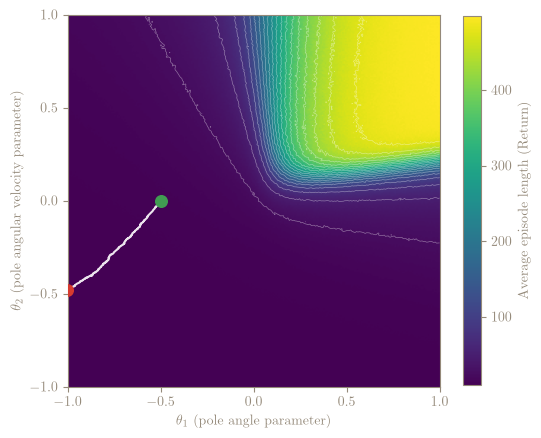

In [24]:
plot_training_path(traj_nolog, save_name='pg_nolog_path.svg')

<Axes: xlabel='Learning step', ylabel='Return (episode length)'>

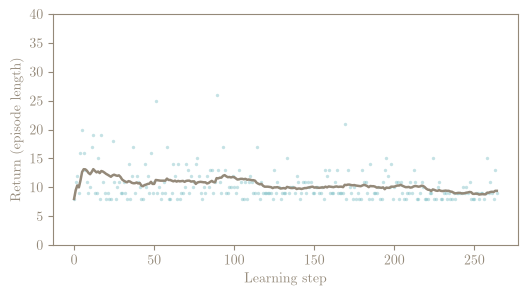

In [25]:
plot_training_rewards(hist_nolog, window=25, ylim=(0, 40), save_name='pg_nolog_rewards.svg')   # zoomed: returns stay short here

## 3. Return-to-go
$$
\theta \leftarrow \theta + \alpha \sum_{t=1}^{T} G_t \, \nabla_{\theta} \log p_{\theta}(a_t \mid s_t),
\qquad G_t = \sum_{t'=t}^{T} r_{t'} = T - t + 1
$$
- Same learning rate and seeds as run 1, so the two are directly comparable.

- Hmm ok so I do want to show some derviation of the step level form of the policy gradient, let's see here...

$$
\nabla_{\theta} J(\theta)
= \mathbb{E}_{\tau \sim p_\theta} \big[ R(\tau) \nabla_{\theta} \log p_{\theta}(\tau) \big]
$$

Ok yeah so I think we go back to the full 7 term environmental version now! That will be cool to show from 2 persepctives, here and earlier, log is kinda going to be magic!
$$
p_\theta(\tau) = p(s_1) \cdot p_\theta(a_1 \mid s_1) \cdot p(s_2 \mid s_1, a_1) \cdot p_\theta(a_2 \mid s_2) \cdot p(s_3 \mid s_2, a_2) \cdot p_\theta(a_3 \mid s_3) \cdot p(s_4 \mid s_3, a_3)
$$

$$
\log p_\theta(\tau) = \log p(s_1) + \log p_\theta(a_1 \mid s_1) + \log p(s_2 \mid s_1, a_1) + \log p_\theta(a_2 \mid s_2) + \log p(s_3 \mid s_2, a_2) + \log p_\theta(a_3 \mid s_3) + \log p(s_4 \mid s_3, a_3)
$$

$$
\nabla_\theta \log p_\theta(\tau) = \nabla_\theta \log p(s_1) + \nabla_\theta \log p_\theta(a_1 \mid s_1) + \nabla_\theta \log p(s_2 \mid s_1, a_1) + \nabla_\theta \log p_\theta(a_2 \mid s_2) + \nabla_\theta \log p(s_3 \mid s_2, a_2) + \nabla_\theta \log p_\theta(a_3 \mid s_3) + \nabla_\theta \log p(s_4 \mid s_3, a_3)
$$


$$
\nabla_\theta \log p_\theta(\tau) = \sum_{t=1}^{3} \nabla_\theta \log p_\theta(a_t \mid s_t)
$$

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim p_\theta} \Big[ R(\tau) \sum_{t=1}^{3} \nabla_\theta \log p_\theta(a_t \mid s_t) \Big]
$$

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim p_\theta} \Big[ \sum_{t=1}^{3} R(\tau)  \nabla_\theta \log p_\theta(a_t \mid s_t) \Big]
$$

This is kinda a nice way to show what's going on:

$$
3 \cdot \nabla_\theta \log p_\theta(a_1 \mid s_1) + 3 \cdot \nabla_\theta \log p_\theta(a_2 \mid s_2) + 3 \cdot \nabla_\theta \log p_\theta(a_3 \mid s_3)
$$
$$
3 \cdot \nabla_\theta \log p_\theta(a_2 \mid s_2) + 2 \cdot \nabla_\theta \log p_\theta(a_3 \mid s_3) + 1 \cdot \nabla_\theta \log p_\theta(a_3 \mid s_3)
$$

$$
\nabla_{\theta} J(\theta)
= \mathbb{E}_{\tau \sim p_\theta} \bigg[ \sum_{t=1}^{T} R_t(\tau) \nabla_{\theta} \log p_{\theta}(a_t \mid s_t) \bigg]
$$

Double sum formulation

$$
\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T_i} R_t(\tau_i)\, \nabla_\theta \log p_\theta(a_{i,t} \mid s_{i,t}), \qquad \tau_i \sim p_\theta
$$

Chatting with claude about why we can move rewards around. 

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim p_\theta} \Big[ \sum_{t=1}^{3} \nabla_\theta \log p_\theta(a_t \mid s_t) \sum_{t'=t}^{3} r_{t'} \Big]
$$

In [26]:
LR_RTG = 4e-5 #2e-5 Ok cool doubling the learning rate seems to kinda work. 

hist_rtg, traj_rtg, agent_rtg = train_pg(weighting='rtg', theta_0=THETA_0, lr=LR_RTG,
                                         max_steps=3000, stop_after_first_500=1)

 13%|████▍                             | 394/3000 [00:00<00:01, 1972.92it/s]

step     0  mean R    8.0  theta = (-0.500, +0.000)
step   100  mean R   10.0  theta = (-0.481, +0.028)
step   200  mean R   10.0  theta = (-0.440, +0.077)
step   300  mean R   13.0  theta = (-0.427, +0.122)


 20%|██████▊                           | 599/3000 [00:00<00:01, 1511.06it/s]

step   400  mean R   15.0  theta = (-0.358, +0.176)
step   500  mean R   15.0  theta = (-0.236, +0.242)
first all-500 step: 598
600 steps, 600 episodes, final theta = (+0.524, +0.290)


<Axes: xlabel='$\\theta_1$ (pole angle parameter)', ylabel='$\\theta_2$ (pole angular velocity parameter)'>

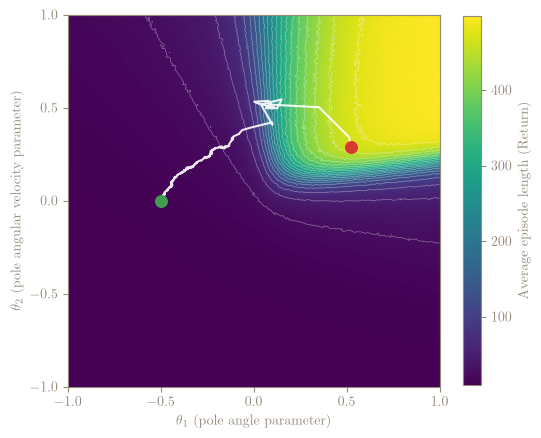

In [27]:
plot_training_path(traj_rtg, save_name='pg_rtg_path.svg')

<Axes: xlabel='Learning step', ylabel='Return (episode length)'>

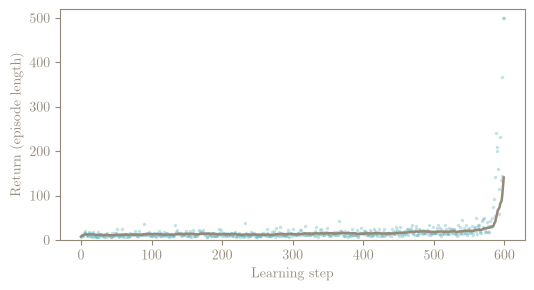

In [28]:
plot_training_rewards(hist_rtg, window=25, save_name='pg_rtg_rewards.svg')

## Low Step Version of L1

In [29]:
import json
import torch.optim as optim

In [30]:
with open(DATA / "sw_cartpole_game.json") as f: 
    data = json.load(f)

VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
obs = torch.tensor(data["episodes"][0]["observations"]) 
X = obs[:, 2:4] * 180/np.pi # Here we'll just use pole angle and pole angular velocity, and use degrees
X[:,1] = X[:,1] / VEL_SCALE # Scale pole angular velocity
y = torch.tensor(data['episodes'][0]['actions'])

agent=Pi()

In [31]:
def l1_loss(yhat, y):
    return (y-yhat).abs().mean()

In [32]:
def plot_loss_landscape(ax, L_vals, theta1_vals, theta2_vals, levels=18, labels=True): #Helper
    extent = [theta1_vals[0], theta1_vals[-1], theta2_vals[0], theta2_vals[-1]]
    im = ax.imshow(L_vals.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')  # .T -> theta1 on x
    T1, T2 = np.meshgrid(theta1_vals, theta2_vals)
    cs = ax.contour(T1, T2, L_vals.T, levels=levels, colors='w', linewidths=0.5, alpha=0.7)
    if labels: ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f', colors='w')
    ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    return im

In [33]:
theta_0 = torch.tensor([-0.7, -0.1])

In [34]:
theta1_vals_viz = np.linspace(-1.5, 1.5, 128)
theta2_vals_viz = np.linspace(-1.5, 1.5, 128)   # span matches theta1 -> square extent

agent = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            agent.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(agent(X), y)         # same loss, same data as training

100%|████████████████████████████████████| 128/128 [00:00<00:00, 643.19it/s]


In [35]:
lr = 1e-2  
steps = 1000

agent = Pi()
with torch.no_grad():
    agent.theta[:] = theta_0
opt = optim.SGD(agent.parameters(), lr=lr) 

traj, losses = [agent.theta.detach().clone()], []
for step in range(steps):
    loss = l1_loss(agent(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    traj.append(agent.theta.detach().clone()); losses.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        acc = ((agent(X) >= 0.5).int() == y).float().mean().item()
        print(f'step {step:5d}  loss {loss.item():7.3f}  acc {acc:.3f}  theta = ({agent.theta[0]:+.3f}, {agent.theta[1]:+.3f})')
    
traj = torch.stack(traj).numpy()   

step     0  loss   0.711  acc 0.197  theta = (-0.699, -0.100)
step   100  loss   0.698  acc 0.197  theta = (-0.585, -0.118)
step   200  loss   0.671  acc 0.227  theta = (-0.425, -0.149)
step   300  loss   0.581  acc 0.348  theta = (-0.133, -0.189)
step   400  loss   0.362  acc 0.742  theta = (+0.318, -0.095)
step   500  loss   0.311  acc 0.803  theta = (+0.531, -0.042)
step   600  loss   0.294  acc 0.773  theta = (+0.659, -0.020)
step   700  loss   0.284  acc 0.773  theta = (+0.756, -0.006)
step   800  loss   0.277  acc 0.773  theta = (+0.838, +0.005)
step   900  loss   0.272  acc 0.773  theta = (+0.909, +0.015)
step   999  loss   0.268  acc 0.788  theta = (+0.973, +0.024)


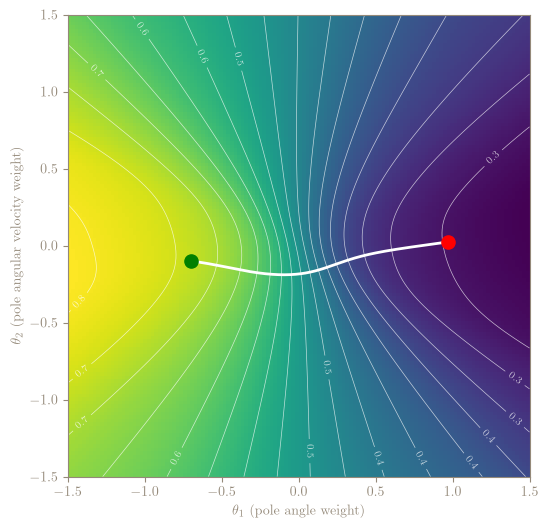

In [36]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
im = plot_loss_landscape(ax, L_vals, theta1_vals_viz, theta2_vals_viz)
ax.plot(traj[:, 0], traj[:, 1], color='w', lw=2, alpha=1.0, zorder=4)
# ax.scatter(traj[:, 0], traj[:, 1], color='w', s=20)
u = -agent.theta.grad.numpy()*5
# ax.annotate('', xy=traj[-1] + u, xytext=traj[-1], arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18), zorder=6)
ax.scatter(*traj[0],  s=90, color='g', zorder=10, label='start')
ax.scatter(*traj[-1], s=90, color='r', zorder=10, label='end')
# ax.legend(); plt.title('Gradient descent path')
style_ax(ax)
plt.savefig(SAVE_DIR + '/' + 'low_step_l1_lr_1e2.svg')

In [37]:
lr = 1e-1 
steps = 100

agent = Pi()
with torch.no_grad():
    agent.theta[:] = theta_0
opt = optim.SGD(agent.parameters(), lr=lr) 

traj, losses = [agent.theta.detach().clone()], []
for step in range(steps):
    loss = l1_loss(agent(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    traj.append(agent.theta.detach().clone()); losses.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        acc = ((agent(X) >= 0.5).int() == y).float().mean().item()
        print(f'step {step:5d}  loss {loss.item():7.3f}  acc {acc:.3f}  theta = ({agent.theta[0]:+.3f}, {agent.theta[1]:+.3f})')
    
traj = torch.stack(traj).numpy()   

step     0  loss   0.711  acc 0.197  theta = (-0.690, -0.101)
step    99  loss   0.268  acc 0.788  theta = (+0.975, +0.023)


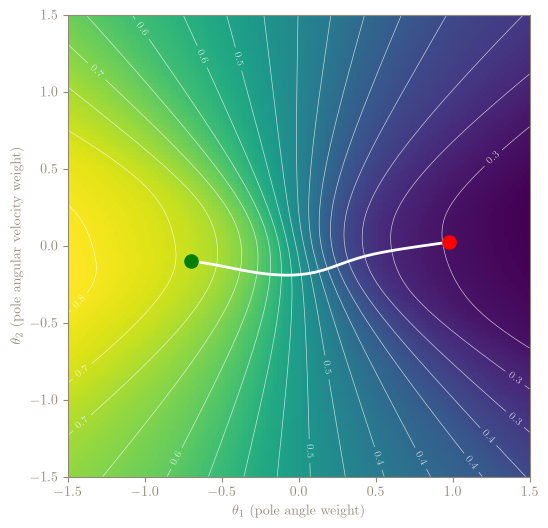

In [38]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
im = plot_loss_landscape(ax, L_vals, theta1_vals_viz, theta2_vals_viz)
ax.plot(traj[:, 0], traj[:, 1], color='w', lw=2, alpha=1.0, zorder=4)
# ax.scatter(traj[:, 0], traj[:, 1], color='w', s=20)
u = -agent.theta.grad.numpy()*5
# ax.annotate('', xy=traj[-1] + u, xytext=traj[-1], arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18), zorder=6)
ax.scatter(*traj[0],  s=90, color='g', zorder=10, label='start')
ax.scatter(*traj[-1], s=90, color='r', zorder=10, label='end')
# ax.legend(); plt.title('Gradient descent path')
style_ax(ax)
plt.savefig(SAVE_DIR + '/' + 'low_step_l1_lr_1e1.svg')

In [39]:
lr = 2.0   
steps = 5

agent = Pi()
with torch.no_grad():
    agent.theta[:] = theta_0
opt = optim.SGD(agent.parameters(), lr=lr) 

traj, losses = [agent.theta.detach().clone()], []
for step in range(steps):
    loss = l1_loss(agent(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    traj.append(agent.theta.detach().clone()); losses.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        acc = ((agent(X) >= 0.5).int() == y).float().mean().item()
        print(f'step {step:5d}  loss {loss.item():7.3f}  acc {acc:.3f}  theta = ({agent.theta[0]:+.3f}, {agent.theta[1]:+.3f})')
    
traj = torch.stack(traj).numpy()   

step     0  loss   0.711  acc 0.212  theta = (-0.499, -0.125)
step     4  loss   0.271  acc 0.773  theta = (+1.058, -0.003)


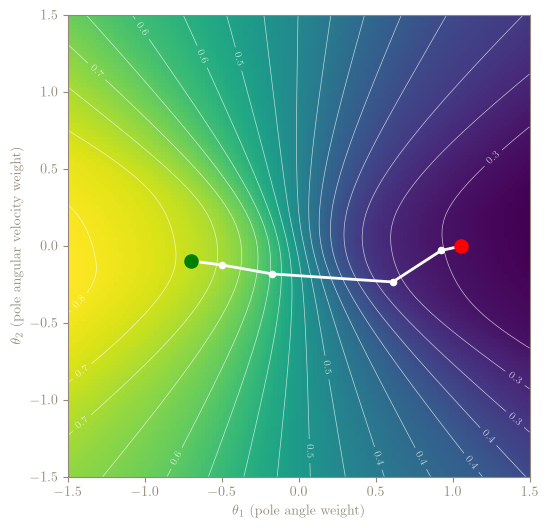

In [40]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
im = plot_loss_landscape(ax, L_vals, theta1_vals_viz, theta2_vals_viz)
ax.plot(traj[:, 0], traj[:, 1], color='w', lw=2, alpha=1.0, zorder=4)
ax.scatter(traj[:, 0], traj[:, 1], color='w', s=20)
u = -agent.theta.grad.numpy()*5
# ax.annotate('', xy=traj[-1] + u, xytext=traj[-1], arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18), zorder=6)
ax.scatter(*traj[0],  s=90, color='g', zorder=10, label='start')
ax.scatter(*traj[-1], s=90, color='r', zorder=10, label='end')
# ax.legend(); plt.title('Gradient descent path')
style_ax(ax)
plt.savefig(SAVE_DIR + '/' + 'low_step_l1_lr_2.svg')

## 4. GRPO, 4 episodes per step
$$
A_i = \frac{R_i - \operatorname{mean}(R_1, \ldots, R_G)}{\operatorname{std}(R_1, \ldots, R_G)},
\qquad
\theta \leftarrow \theta + \alpha \, \frac{1}{G} \sum_{i=1}^{G} A_i \sum_{t=1}^{T_i} \nabla_{\theta} \log p_{\theta}(a_{i,t} \mid s_{i,t})
$$
- Single on-policy update per group, so the importance ratio is 1 and there's no clip/KL term.
- Advantages are $O(1)$, so the learning rate is much bigger than runs 1 and 3. Once a whole group hits 500 the advantages all vanish and the update is zero.
- Reward plot: faint dots are all 4 episodes at each step, line is the group mean (lightly smoothed).

In [75]:
GROUP_SIZE = 4
LR_GRPO    = 4e-3 #3e-3

hist_grpo, traj_grpo, agent_grpo = train_pg(weighting='grpo', group_size=GROUP_SIZE, theta_0=THETA_0, lr=LR_GRPO,
                                            max_steps=600, stop_after_first_500=1, print_every=20)

  7%|██▌                                  | 41/600 [00:00<00:01, 403.32it/s]

step     0  mean R   10.0  theta = (-0.500, +0.000)
step    20  mean R   13.0  theta = (-0.466, +0.044)
step    40  mean R   12.2  theta = (-0.365, +0.192)
step    60  mean R   53.2  theta = (-0.029, +0.469)


 14%|█████▏                                | 82/600 [00:00<00:06, 86.07it/s]

step    80  mean R  413.0  theta = (+0.461, +0.604)


 15%|█████▋                                | 89/600 [00:01<00:06, 75.71it/s]

first all-500 step: 88
90 steps, 360 episodes, final theta = (+0.518, +0.655)


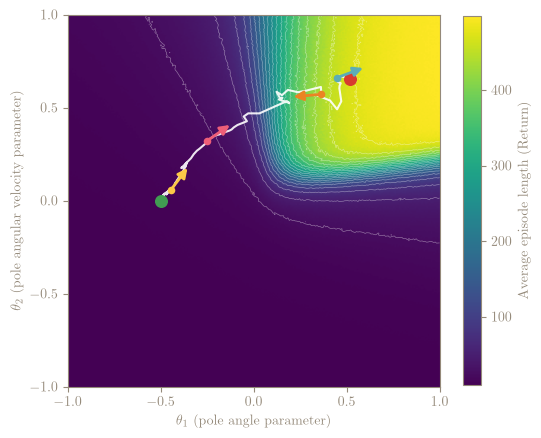

In [120]:
GRAD_STEPS = [25, 50, 75, 85]   # training steps to mark
ARROW_LEN  = 0.15              # arrow length in theta units (direction only, every arrow is the same length)

colors=[YELLOW, PINK, ORANGE, LT_BLUE]

ax = plot_training_path(traj_grpo)
count=0
for s in [s for s in GRAD_STEPS if s < len(hist_grpo)]:
    p = traj_grpo[s]                    # theta that played step s
    g = hist_grpo[s]['grad']            # ascent direction estimated at step s
    n = np.linalg.norm(g)
    if n > 0:
        ax.annotate('', xy=p + ARROW_LEN * g / n, xytext=p, zorder=11,
                    arrowprops=dict(arrowstyle='-|>', color=colors[count], lw=2, mutation_scale=14, shrinkA=0, shrinkB=0))
    ax.scatter(*p, s=30, color=colors[count], linewidths=0, zorder=12)
    count+=1
plt.savefig(SAVE_DIR + '/pg_grpo_path_grads.svg', bbox_inches='tight')

In [112]:
# plot_training_path(traj_grpo, save_name='pg_grpo_path.svg')

In [113]:
# plot_training_rewards(hist_grpo, window=3, save_name='pg_grpo_rewards.svg')

### GRPO supporting plots (starting point)
- One row per training step: the group's 4 episodes on top of the policy that played them, labeled with return and advantage.

In [123]:
print(hist_grpo[85]['Rs'], hist_grpo[85]['advs'], hist_grpo[85]['grad'])

[500. 360. 500. 494.] [ 0.61030731 -1.73059744  0.61030731  0.50998282] [2.306149  0.8595481]


In [124]:
GRPO_STEPS=GRAD_STEPS

In [125]:
GRPO_STEPS

[25, 50, 75, 85]

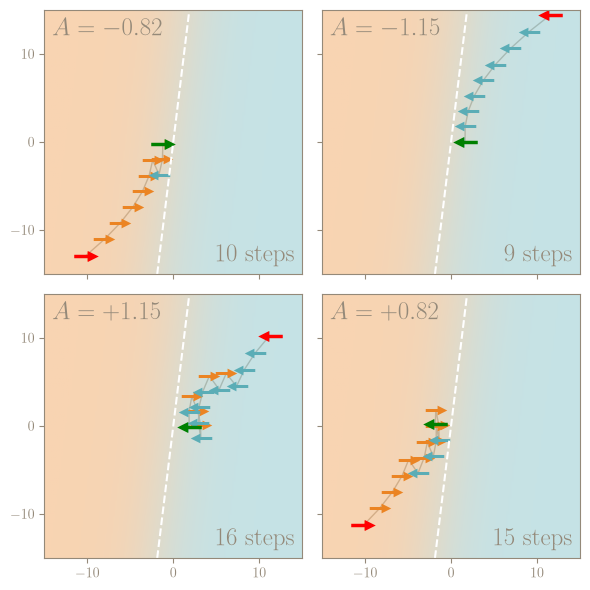

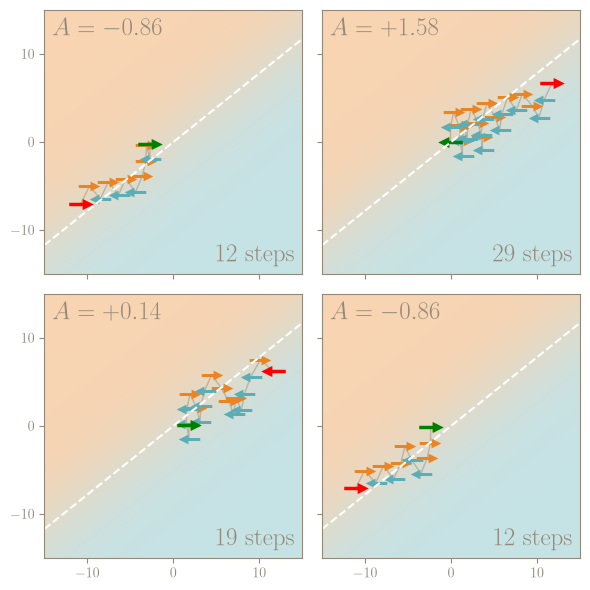

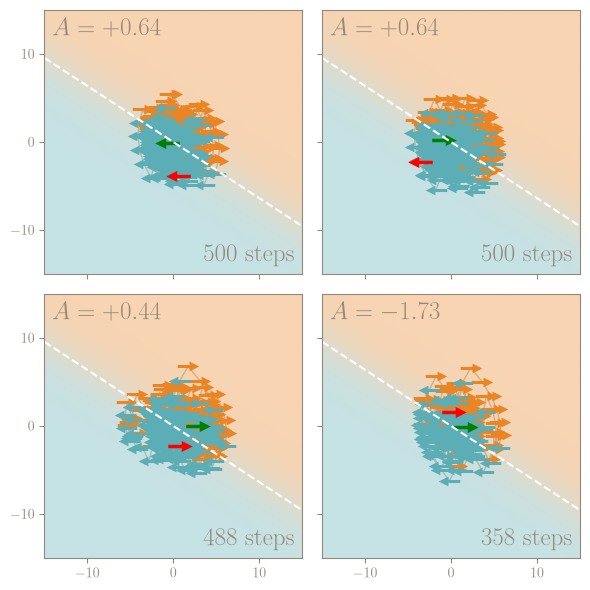

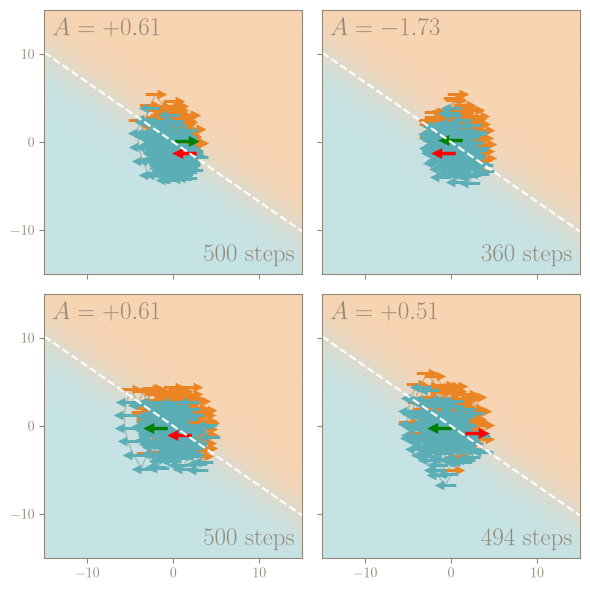

In [127]:
# GRPO_STEPS = [0, 30, 60, 85]   # training steps to show, one 2x2 figure each
GRPO_STEPS = [s for s in GRPO_STEPS if s < len(hist_grpo)]

for s in GRPO_STEPS:
    h = hist_grpo[s]
    fig, axs = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
    for ax, (X_ep, y_ep), A in zip(axs.ravel(), h['episodes'], h['advs']):
        plot_snapshot(ax, h['theta'], X_ep, y_ep, s=240, label=f'$A = {A:+.2f}$')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + f'/pg_grpo_group_step_{s:03d}.svg', bbox_inches='tight')
    plt.show()

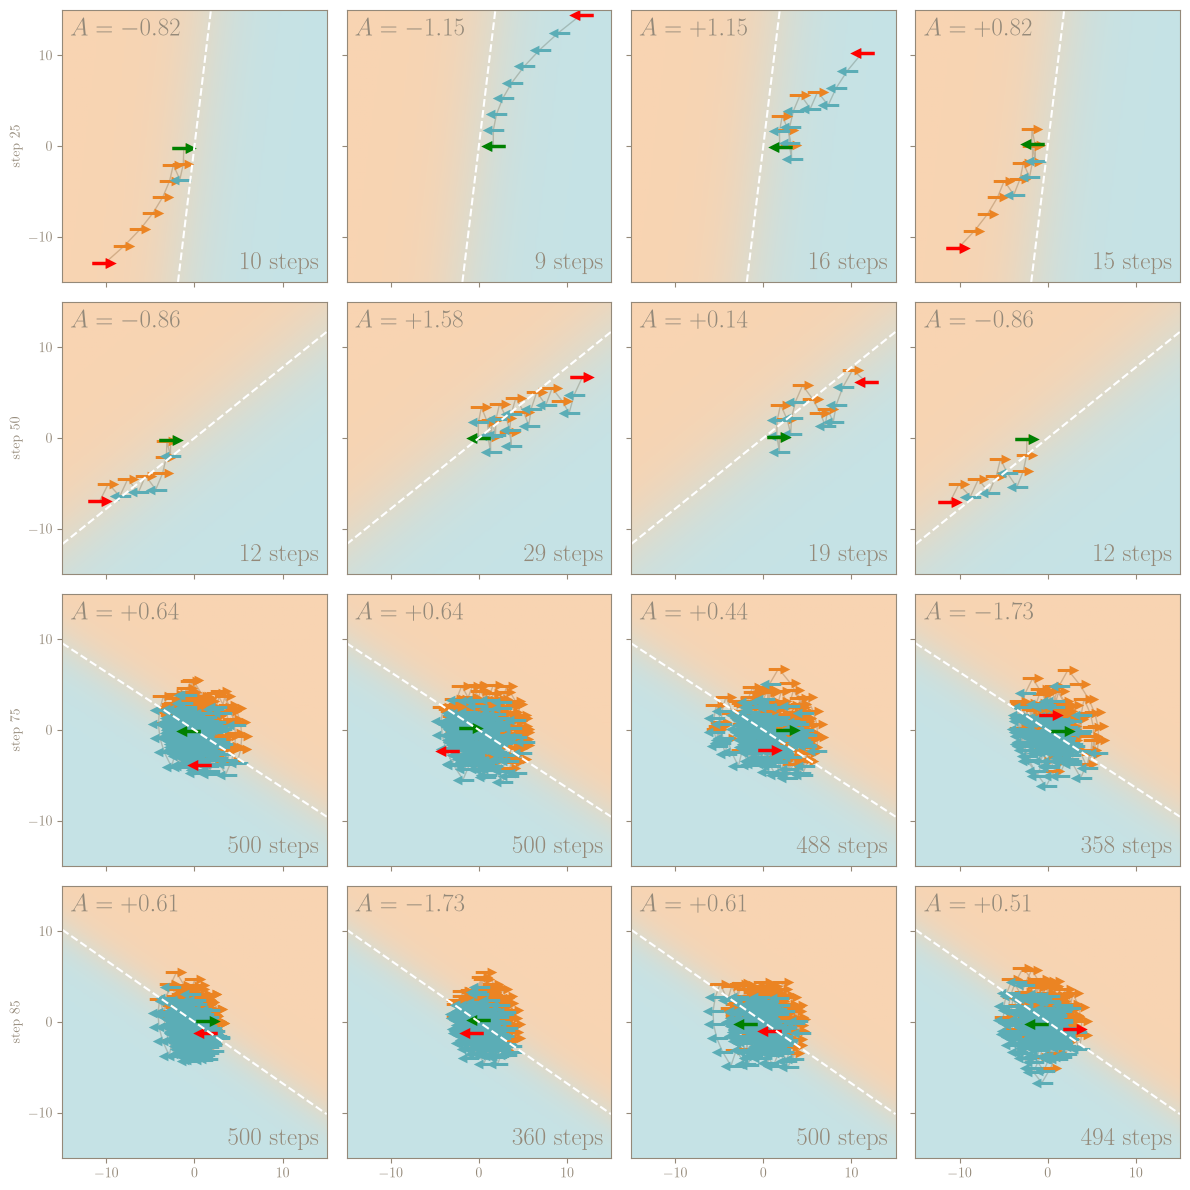

In [126]:
# GRPO_STEPS = [0, 30, 60, 88]   # training steps to show
GRPO_STEPS = [s for s in GRPO_STEPS if s < len(hist_grpo)]

fig, axs = plt.subplots(len(GRPO_STEPS), GROUP_SIZE, figsize=(3*GROUP_SIZE, 3*len(GRPO_STEPS)), sharex=True, sharey=True, squeeze=False)
for row, s in zip(axs, GRPO_STEPS):
    h = hist_grpo[s]
    for ax, (X_ep, y_ep), A in zip(row, h['episodes'], h['advs']):
        plot_snapshot(ax, h['theta'], X_ep, y_ep, s=240, label=f'$A = {A:+.2f}$')
    row[0].set_ylabel(f'step {s}')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/pg_grpo_groups.svg', bbox_inches='tight')

In [115]:
GRAD_STEPS

[25, 50, 75, 85]